In [1]:
###  Problem Generator

import pickle
import numpy as np
from scipy.stats import truncnorm
from scipy.spatial.distance import cdist
import xgboost as xgb
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

np.random.seed(2026)

## Define median-based ensemble of surrogates
class medClassifier:
    def __init__(self, classifiers=None):
        self.classifiers = classifiers

    def predict(self, X):
        self.predictions_ = []
        for classifier in self.classifiers:
            try:
                self.predictions_.append(classifier.predict(X))
            except:
                X = xgb.DMatrix(X)
                self.predictions_.append(classifier.predict(X))
        med1 = np.median(self.predictions_, axis=0)
        mean1 = np.mean(self.predictions_, axis=0)
        # out = med1 + np.random.rand() * np.abs(med1 - mean1)
        out = med1 
        return out

## main windfram problem generator
class WindFarmProblem:
    def __init__(self, ensemble_file="Ensemble.pkl",  # model used for obj1
                 rotor_diameter=126,                   
                 farm_length=333.33 * 5,
                 n_turbines=5,
                 nr_birds=1000,
                 bird_mean=-25000,
                 x_sigma=5,  # decide std and the bird group distribution
                 n_fields=5, # number of the oil/gas fileds
                 seed=2026): # random seed

        self.seed = seed
        self.rng_fields = np.random.default_rng(seed)
        self.rng_plot = np.random.default_rng(seed + 1)

        self.rotor_diameter = rotor_diameter
        self.farm_length = farm_length
        self.n_turbines = n_turbines
        self.nr_birds = nr_birds
        self.bird_mean = bird_mean
        self.x_sigma = x_sigma

        # It generates n fields when n_fields is an int or it generates using input list as coordinates
        self.fields = self._generate_oil_fields(n_fields)
        self.n_fields = len(self.fields)

        with open(ensemble_file, "rb") as file:
            self.ensemble = pickle.load(file)

    ## turn [x1, x2,...y1, y2...] into [[x1,y1], [x2, y2]]
    def _to_coords(self, x):   
        x = np.asarray(x, dtype=float)
        xs = x[:self.n_turbines]
        ys = x[self.n_turbines:]
        coords = np.column_stack((xs, ys))
        return coords

    ##  fields generation using coordinates list
    def _validate_field_list(self, field_list): 
        """
        field_list format:
        [
            (xmin, xmax, ymin, ymax),
            ...
        ]
        """
        if len(field_list) > 5:
            raise ValueError("At most 5 oil fields are allowed.")

        validated = []
        for i, field in enumerate(field_list):
            if len(field) != 4:
                raise ValueError(f"Field {i} must have 4 values: (xmin, xmax, ymin, ymax).")

            xmin, xmax, ymin, ymax = map(float, field)

            if not (0 <= xmin < xmax <= 1):
                raise ValueError(
                    f"Field {i} has invalid x-range: require 0 <= xmin < xmax <= 1, got {(xmin, xmax)}"
                )
            if not (0 <= ymin < ymax <= 1):
                raise ValueError(
                    f"Field {i} has invalid y-range: require 0 <= ymin < ymax <= 1, got {(ymin, ymax)}"
                )

            validated.append((xmin, xmax, ymin, ymax))

        return validated

    ## generate random oil fields OR use provided oil field list
    def _generate_oil_fields(self, n_fields):
        # case 1: n_fields is an integer -> random generation
        if isinstance(n_fields, int):
            fields = []
            n_fields = min(n_fields, 5)

            for _ in range(n_fields):
                width = self.rng_fields.uniform(0.05, 0.5)
                height = self.rng_fields.uniform(0.05, 0.5)

                xmin = self.rng_fields.uniform(0, 1 - width)
                ymin = self.rng_fields.uniform(0, 1 - height)

                xmax = xmin + width
                ymax = ymin + height

                fields.append((xmin, xmax, ymin, ymax))

            return fields

        # case 2: n_fields is a list/tuple/ndarray of coordinates
        elif isinstance(n_fields, (list, tuple, np.ndarray)):
            return self._validate_field_list(list(n_fields))

        else:
            raise TypeError(
                "n_fields must be either an int or a list of field coordinates "
                "[(xmin, xmax, ymin, ymax), ...]"
            )

    ## using ensemble model to predict the obj1
    def objective1(self, x): 
        x = np.array([x])
        pred = self.ensemble.predict(x)
        return pred[0]

    ## calculaate the percentage of birds are too close
    def objective2(self, x): 
        x = np.array([x])
        coords = np.resize(x, (2, self.n_turbines))

        bird_std = 25000 / self.x_sigma
        birds = truncnorm.rvs(
            self.x_sigma,
            self.x_sigma + self.farm_length / bird_std,
            loc=self.bird_mean,
            scale=bird_std,
            size=self.nr_birds,
            random_state=2026
        )

        leftmost = np.min(coords[0]) * self.farm_length
        threshold = leftmost - self.rotor_diameter
        close_birds = np.sum(birds >= threshold) / self.nr_birds
        return close_birds

    ## calculate the total length of cables connecting turbos
    def objective3(self, x, order): 
        coords = self._to_coords(x)

        turbine_order = order[:-1]
        hub = np.array(order[-1], dtype=float)

        total_length = 0.0
        current_point = hub

        for turb_id in turbine_order:
            turb_coord = coords[turb_id - 1]
            total_length += np.linalg.norm(turb_coord - current_point)
            current_point = turb_coord

        return total_length * self.farm_length
        
    ## Constraint1 is that the distances between two turbos should be bigger than 2 * self.rotor_diameter
    ## cv is the constaint1 violation;
    def constraint1(self, x):  
        coords = self._to_coords(x)

        min_dist = np.inf
        for turb in range(self.n_turbines - 1):
            dists = cdist([coords[turb]], coords[turb + 1:])
            next_min = np.min(dists)
            if next_min < min_dist:
                min_dist = next_min

        cv = 2 * self.rotor_diameter - min_dist * self.farm_length
        return cv

    ## constraint2 is that the turbo should not locate in a gas/oil filed; n_inside is the constaint1 violation
    def constraint2(self, x):
        coords = self._to_coords(x)
        n_inside = 0

        for xi, yi in coords:
            for xmin, xmax, ymin, ymax in self.fields:
                if xmin <= xi <= xmax and ymin <= yi <= ymax:
                    n_inside += 1
                    break

        return n_inside

        
    ## evaluate all the objs and cons
    def evaluate(self, x, order):
        return {
            "f1": self.objective1(x),
            "f2": self.objective2(x),
            "f3": self.objective3(x, order),
            "g1": self.constraint1(x),
            "g2": self.constraint2(x)
        }

    ## plot the problem and the solution
    def plot_layout(self, x, order):
        coords = self._to_coords(x)

        turbine_order = order[:-1]
        hub = np.array(order[-1], dtype=float)

        fig, ax = plt.subplots(figsize=(7, 7))

        # 1x1 windfarm area
        farm_rect = Rectangle((0, 0), 1, 1, fill=False, edgecolor='blue', linewidth=2)
        ax.add_patch(farm_rect)

        # gas/oil fields
        for i, (xmin, xmax, ymin, ymax) in enumerate(self.fields, start=1):
            rect = Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                facecolor='orange',
                edgecolor='red',
                alpha=0.35
            )
            ax.add_patch(rect)

            ax.text(
                (xmin + xmax) / 2,
                (ymin + ymax) / 2,
                f'field{i}',
                ha='center',
                va='center',
                fontsize=9
            )

        # turbos
        ax.scatter(coords[:, 0], coords[:, 1], s=80, marker='o', label='Turbines')
        for i, (tx, ty) in enumerate(coords, start=1):
            ax.text(tx + 0.015, ty + 0.015, f'T{i}', fontsize=10)

        # hub
        ax.scatter(hub[0], hub[1], s=120, marker='s', label='Hub')
        ax.text(hub[0] + 0.015, hub[1] + 0.015, 'Hub', fontsize=10)

        # cables
        route_points = [hub]
        for turb_id in turbine_order:
            route_points.append(coords[turb_id - 1])

        route_points = np.array(route_points)
        ax.plot(route_points[:, 0], route_points[:, 1], '-o', linewidth=1.5)

        # birds group
        bird_std = 25000 / self.x_sigma
        birds_m = truncnorm.rvs(
            self.x_sigma,
            self.x_sigma + self.farm_length / bird_std,
            loc=self.bird_mean,
            scale=bird_std,
            size=300,
            random_state=2026
        )

        birds_x = birds_m / self.farm_length
        birds_y = self.rng_plot.uniform(0, 1, size=len(birds_x))

        ax.scatter(birds_x, birds_y, s=10, alpha=0.3, label='Birds')

        ax.set_xlim(0, 1.6)
        ax.set_ylim(0, 1.6)

        ax.set_aspect('equal')
        ax.set_title('Wind Farm Layout')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()



In [3]:
###  Generate a new problem
problem = WindFarmProblem(
                         # ensemble_file="Ensemble.pkl",
                         ensemble_file=r"Ensemble.pkl",
                         rotor_diameter=126,
                         farm_length=333.33*5,
                         n_turbines=5,
                         nr_birds=1000,
                         bird_mean=-25000,
                         x_sigma=12,
                         n_fields=[(0.10, 0.30, 0.17, 0.40),
                                   (0.50, 0.80, 0.01, 0.20),
                                   (0.60, 0.90, 0.60, 0.85),],
                         )

In [5]:
import time
import numpy as np
import pandas as pd
import torch

from torch.quasirandom import SobolEngine

from botorch.models import SingleTaskGP, ModelListGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.multi_objective.logei import qLogNoisyExpectedHypervolumeImprovement
from botorch.acquisition.multi_objective.objective import IdentityMCMultiOutputObjective
from botorch.optim import optimize_acqf

from gpytorch.mlls.sum_marginal_log_likelihood import SumMarginalLogLikelihood
from botorch.sampling.normal import SobolQMCNormalSampler



# Settings
N_EVAL = 500
N_INIT = 50
SEED = 2026

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cpu")
dtype = torch.double

N_TURBINES = problem.n_turbines
DIM_X = 2 * N_TURBINES
DIM_PRIORITY = N_TURBINES
DIM_HUB = 2
DIM = DIM_X + DIM_PRIORITY + DIM_HUB



# Decode internal optimizer vector -> x, order
def decode_solution(candidate, n_turbines):
    candidate = np.asarray(candidate, dtype=float)

    # x = [x1,...,xn,y1,...,yn]
    x = candidate[: 2 * n_turbines]

    # priorities -> permutation 1..n
    priorities = candidate[2 * n_turbines : 3 * n_turbines]
    perm = (np.argsort(priorities) + 1).tolist()

    # hub in [1.5, 1.6]^2
    hub = candidate[3 * n_turbines : 3 * n_turbines + 2].tolist()

    order = perm + [hub]
    return x, order


# evaluation 
def evaluate_blackbox(candidate_np: np.ndarray):
    x, order = decode_solution(candidate_np, problem.n_turbines)
    res = problem.evaluate(x, order)

    f1 = float(res["f1"])
    f2 = float(res["f2"])
    f3 = float(res["f3"])
    g1 = float(res["g1"])
    g2 = float(res["g2"])

    return x, order, f1, f2, f3, g1, g2


# Pack outputs for BoTorch
# Objectives are converted to maximization by negation
# Constraints stay as g <= 0
# Y = [-f1, -f2, -f3, g1, g2]
def pack_Y(f1, f2, f3, g1, g2):
    return torch.tensor(
        [[-f1, -f2, -f3, g1, g2]],
        device=device,
        dtype=dtype
    )



# Initial design
sobol = SobolEngine(dimension=DIM, scramble=True, seed=SEED)
X_unit = sobol.draw(N_INIT).to(device=device, dtype=dtype)

# map to actual bounds
# x-part in [0,1]
# priority-part in [0,1]
# hub-part in [1.5,1.6]
X = X_unit.clone()
X[:, -2:] = 1.5 + 0.1 * X[:, -2:]


Y_list = []
records = []

for i in range(N_INIT):
    candidate_np = X[i].cpu().numpy()

    x, order, f1, f2, f3, g1, g2 = evaluate_blackbox(candidate_np)
    Y_list.append(pack_Y(f1, f2, f3, g1, g2))

    feasible = int((g1 <= 0.0) and (g2 <= 0.0))
    records.append({
        "eval_id": i,
        "x": list(x),
        "order": order,
        "f1": f1,
        "f2": f2,
        "f3": f3,
        "g1": g1,
        "g2": g2,
        "feasible": feasible
    })

Y = torch.cat(Y_list, dim=0)   # shape: (N_INIT, 5)


# GP fitting
def fit_model(X_train, Y_train):
    models = []

    for j in range(Y_train.shape[1]):
        gp = SingleTaskGP(
            X_train,
            Y_train[:, j:j+1],
            outcome_transform=Standardize(m=1),
        )
        models.append(gp)

    model = ModelListGP(*models).to(device=device, dtype=dtype)
    mll = SumMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    return model


# Reference point in maximization space
def get_ref_point(Y_train, margin=0.1):
    # first 3 columns are transformed objectives: [-f1,-f2,-f3]
    Y_obj = Y_train[:, :3]
    ref = Y_obj.min(dim=0).values - margin
    return ref


# Bounds
lb = torch.cat([
    torch.zeros(DIM_X, device=device, dtype=dtype),
    torch.zeros(DIM_PRIORITY, device=device, dtype=dtype),
    torch.tensor([1.5, 1.5], device=device, dtype=dtype)
])

ub = torch.cat([
    torch.ones(DIM_X, device=device, dtype=dtype),
    torch.ones(DIM_PRIORITY, device=device, dtype=dtype),
    torch.tensor([1.6, 1.6], device=device, dtype=dtype)
])

bounds = torch.stack([lb, ub])

sampler = SobolQMCNormalSampler(sample_shape=torch.Size([16]))


# BO loop
t_start_total = time.perf_counter()

for t in range(N_INIT, N_EVAL):
    t_start_iter = time.perf_counter()

    model = fit_model(X, Y)
    ref_point = get_ref_point(Y, margin=0.1)

    acq = qLogNoisyExpectedHypervolumeImprovement(
        model=model,
        ref_point=ref_point.tolist(),
        X_baseline=X,
        objective=IdentityMCMultiOutputObjective(outcomes=[0, 1, 2]),
        constraints=[
            lambda samples: samples[..., 3],   # g1 <= 0
            lambda samples: samples[..., 4],   # g2 <= 0
        ],
        sampler=sampler,
    )

    candidate, _ = optimize_acqf(
        acq_function=acq,
        bounds=bounds,
        q=1,
        num_restarts=1,
        raw_samples=20,
        options={"batch_limit": 5, "maxiter": 50},
    )

    x_next_internal = candidate.detach().squeeze(0)
    candidate_np = x_next_internal.cpu().numpy()

    x, order, f1, f2, f3, g1, g2 = evaluate_blackbox(candidate_np)
    y_next = pack_Y(f1, f2, f3, g1, g2)

    X = torch.cat([X, x_next_internal.view(1, -1)], dim=0)
    Y = torch.cat([Y, y_next], dim=0)

    feasible = int((g1 <= 0.0) and (g2 <= 0.0))
    records.append({
        "eval_id": t,
        "x": list(x),
        "order": order,
        "f1": f1,
        "f2": f2,
        "f3": f3,
        "g1": g1,
        "g2": g2,
        "feasible": feasible
    })

    t_end_iter = time.perf_counter()
    iter_time = t_end_iter - t_start_iter


t_end_total = time.perf_counter()
total_time = t_end_total - t_start_total
# print(f"\nTotal EHVI loop time: {total_time:.3f} seconds")


# Save results
df = pd.DataFrame(records)
df.to_csv("ehvi_results.csv", index=False)

print("Saved: ehvi_results.csv")

C:\Users\guoji\anaconda3\envs\python3_11_test\Lib\site-packages\botorch\models\utils\assorted.py:271: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
C:\Users\guoji\anaconda3\envs\python3_11_test\Lib\site-packages\botorch\models\utils\assorted.py:271: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
C:\Users\guoji\anaconda3\envs\python3_11_test\Lib\site-packages\botorch\models\utils\assorted.py:271: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
C:\Users\guoji\anaconda3\envs\python3_11_test\Lib\site-packages\botorch\models\utils\assorted.py:271: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


Saved: ehvi_results.csv


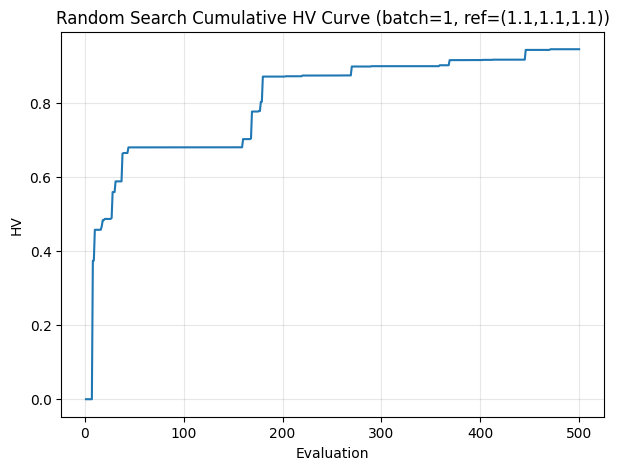

Saved: hv_curve_EHVI_cumulative.png


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.indicators.hv import HV


## Settings
CSV_PATH = r"EHVI_results.csv"
BATCH_SIZE = 1

# reference point
REF_POINT = np.array([1.1, 1.1, 1.1], dtype=float)

# read results
df = pd.read_csv(CSV_PATH)

# Normalization bounds
f_min = np.array([-7.00463867e+01,  2.00000000e-03,  3.84166049e+03], dtype=float)
f_max = np.array([-9.95229626e+00,  1.00000000e+00,  9.26434954e+03], dtype=float)

denom = f_max - f_min


hv_indicator = HV(ref_point=REF_POINT)

xs, hvs = [], []

n = len(df)

# Cumulative HV curve
for end in range(BATCH_SIZE, n + 1, BATCH_SIZE):
    cur = df.iloc[:end]
    cur_feas = cur[cur["feasible"] == 1]

    xs.append(end)

    if len(cur_feas) == 0:
        hvs.append(0.0)
        continue

    # 3-objective minimization values
    F = cur_feas[["f1", "f2", "f3"]].to_numpy(dtype=float)

    # first Pareto front
    fronts = NonDominatedSorting().do(F)
    F_best = F[fronts[0]]

    # normalize to [roughly 0,1]
    F_best_norm = (F_best - f_min) / denom

    hv_value = float(hv_indicator(F_best_norm))
    hvs.append(hv_value)

# handle tail case 
if n % BATCH_SIZE != 0:
    end = n
    cur = df.iloc[:end]
    cur_feas = cur[cur["feasible"] == 1]
    xs.append(end)

    if len(cur_feas) == 0:
        hvs.append(0.0)
    else:
        F = cur_feas[["f1", "f2", "f3"]].to_numpy(dtype=float)
        fronts = NonDominatedSorting().do(F)
        F_best = F[fronts[0]]
        F_best_norm = (F_best - f_min) / denom
        hvs.append(float(hv_indicator(F_best_norm)))

# Plot
plt.figure(figsize=(7, 5))
plt.plot(xs, hvs)
plt.xlabel("Evaluation")
plt.ylabel("HV")
plt.title(f"Random Search Cumulative HV Curve (batch={BATCH_SIZE}, ref=(1.1,1.1,1.1))")
plt.grid(alpha=0.3)
plt.savefig(r"hv_curve_EHVI_cumulative.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: hv_curve_EHVI_cumulative.png")